In [9]:
library(coursekata)
source("../gf_lm_cat.R")   # needed by gf_shuffle_grid
source("../gf_coef.R")
source("../gf_shuffle_grid.R")

# Test cases for `gf_coef()` / `gf_b()`

Three continuous-X scenarios testing where b0 lands relative to the data:
1. **b0 near the data** — x is centered at 0, intercept falls inside the data cloud
2. **b0 far below the data** — x is all large positive values (like Height in inches), intercept is an extrapolation far left
3. **b0 far above the data** — negative slope, x all positive, intercept is above the whole data cloud

b0 = 4.79   x range: -5.99 4.57 


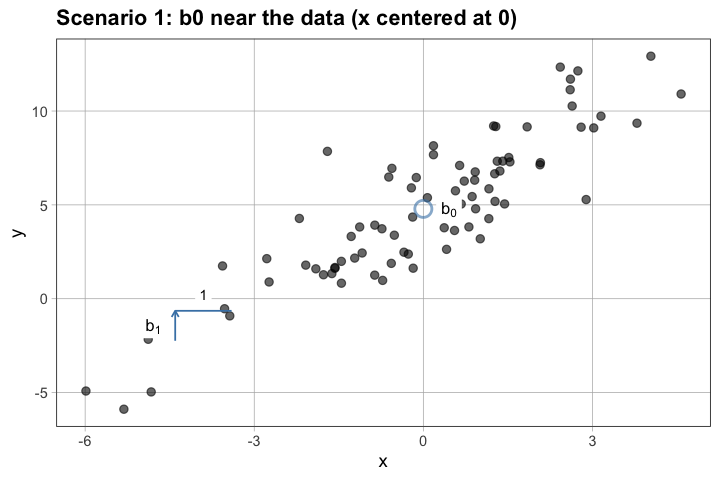

In [10]:
# Scenario 1: b0 NEAR the data
# x centered at 0 so the line at y=b0 (when x=0) falls right in the data
set.seed(42)
n <- 80
d_near <- data.frame(x = rnorm(n, mean = 0, sd = 2))
d_near$y <- 5 + 1.5 * d_near$x + rnorm(n, sd = 2)
m_near <- lm(y ~ x, data = d_near)
cat("b0 =", round(coef(m_near)[1], 2), "  x range:", round(range(d_near$x), 2), "\n")

gf_point(y ~ x, data = d_near) %>%
  gf_coef(m_near, color = "steelblue") +
  labs(title = "Scenario 1: b0 near the data (x centered at 0)")

b0 = -8.17   x range: 55.03 76.15   y range: 43.36 67.37 


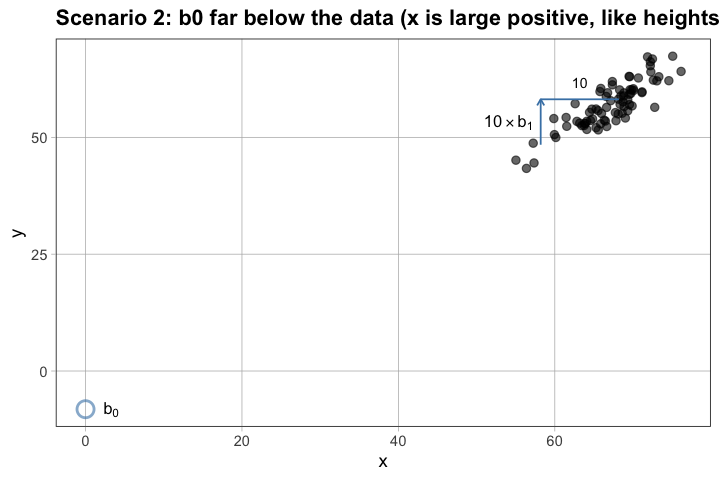

In [11]:
# Scenario 2: b0 FAR BELOW the data
# Like Thumb ~ Height: x ranges ~60-75, so b0 (at x=0) is a huge extrapolation below the plot
set.seed(42)
d_below <- data.frame(x = rnorm(n, mean = 67, sd = 4))   # height-like in inches
d_below$y <- -3 + 0.9 * d_below$x + rnorm(n, sd = 3)    # b0 ≈ -3, data y ≈ 55-70
m_below <- lm(y ~ x, data = d_below)
cat("b0 =", round(coef(m_below)[1], 2), "  x range:", round(range(d_below$x), 2), "  y range:", round(range(d_below$y), 2), "\n")

gf_point(y ~ x, data = d_below) %>%
  gf_coef(m_below, color = "steelblue") +
  labs(title = "Scenario 2: b0 far below the data (x is large positive, like heights)")

b0 = 97.16   x range: 26.06 68.29   y range: 16.14 66.85 


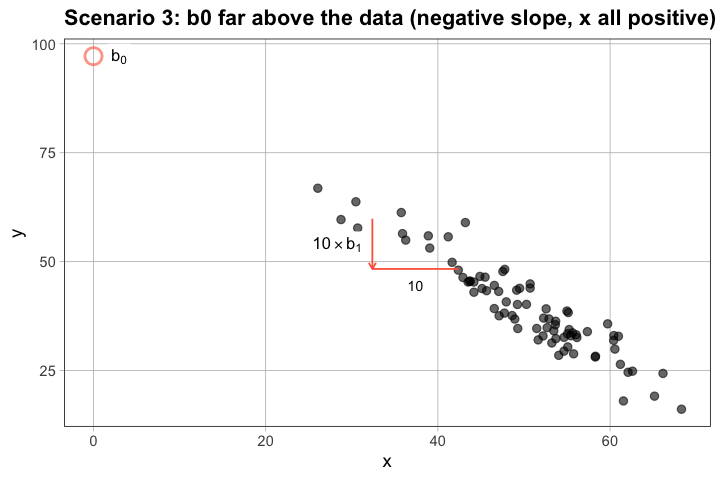

In [12]:
# Scenario 3: b0 FAR ABOVE the data
# Negative slope, x all positive: the line extrapolates up to a high intercept
set.seed(42)
d_above <- data.frame(x = rnorm(n, mean = 50, sd = 8))   # x ranges ~30-70
d_above$y <- 100 - 1.2 * d_above$x + rnorm(n, sd = 4)   # b0 = 100, data y ≈ 20-60
m_above <- lm(y ~ x, data = d_above)
cat("b0 =", round(coef(m_above)[1], 2), "  x range:", round(range(d_above$x), 2), "  y range:", round(range(d_above$y), 2), "\n")

gf_point(y ~ x, data = d_above) %>%
  gf_coef(m_above, color = "tomato") +
  labs(title = "Scenario 3: b0 far above the data (negative slope, x all positive)")

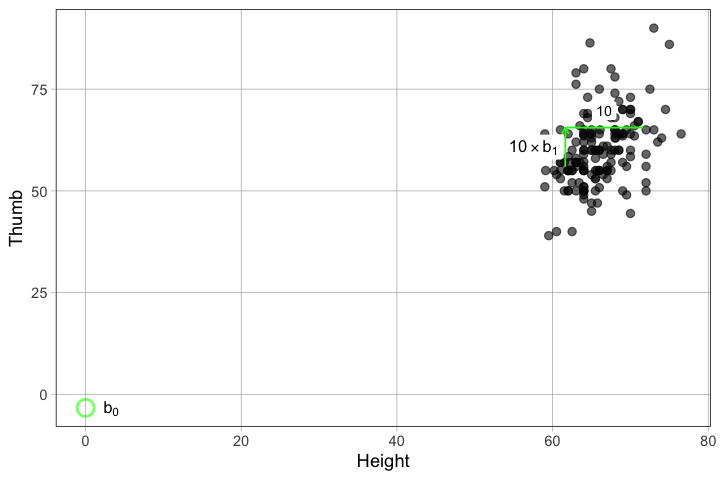

In [13]:
# Run override test — confirm '10 x b1' label appears
library(mosaic)
gf_point(Thumb ~ Height, data = Fingers) %>%
  gf_coef(lm(Thumb ~ Height, data = Fingers), run = 10, color = "green")

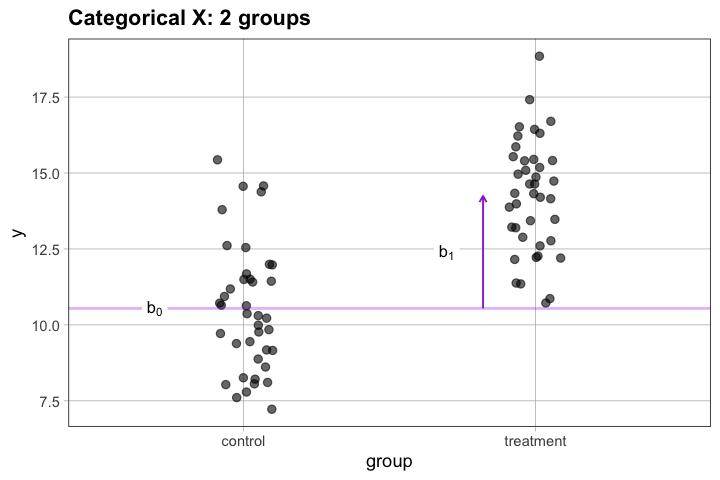

In [14]:
# Categorical X — 2 groups
set.seed(7)
d_cat2 <- data.frame(
  group = factor(rep(c("control", "treatment"), each = 40)),
  y     = c(rnorm(40, mean = 10, sd = 2), rnorm(40, mean = 14, sd = 2))
)
m_cat2 <- lm(y ~ group, data = d_cat2)

gf_jitter(y ~ group, data = d_cat2, width = 0.1) %>%
  gf_coef(m_cat2, color = "purple") +
  labs(title = "Categorical X: 2 groups")

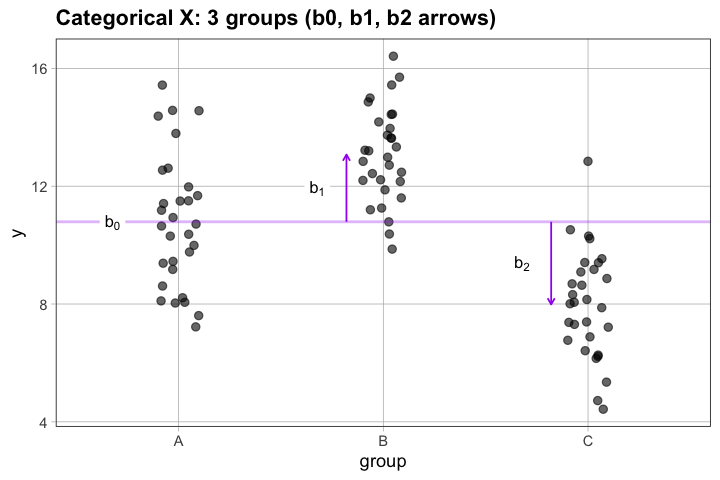

In [15]:
# Categorical X — 3 groups (tests b1 and b2 arrows)
set.seed(7)
d_cat3 <- data.frame(
  group = factor(rep(c("A", "B", "C"), each = 30)),
  y     = c(rnorm(30, mean = 10, sd = 2), rnorm(30, mean = 13, sd = 2), rnorm(30, mean = 8, sd = 2))
)
m_cat3 <- lm(y ~ group, data = d_cat3)

gf_jitter(y ~ group, data = d_cat3, width = 0.1) %>%
  gf_coef(m_cat3, color = "purple") +
  labs(title = "Categorical X: 3 groups (b0, b1, b2 arrows)")

# Test cases for `gf_lm_cat()`

Organized by what could go wrong:
1. **Level ordering** — custom and reversed factor levels
2. **In-formula transformations** — `as.factor()`, `ntile()`, `shuffle()`
3. **Negative b1** — group 2 mean below group 1
4. **NAs in y**
5. **Unbalanced groups**
6. **gf_point vs gf_jitter** — segments should land at means regardless
7. **Continuous x guard** — should error clearly
8. **Chaining with gf_coef()** — both functions together

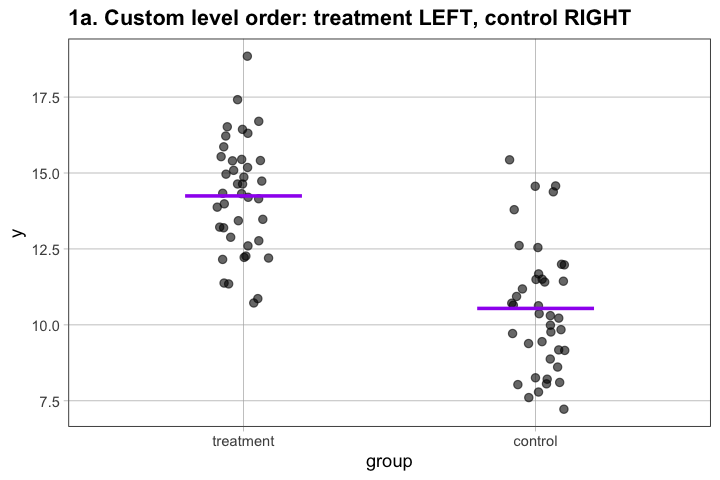

In [16]:
# 1a. Custom level order — segments should follow the factor order, not alphabetical.
#     "treatment" will be level 1 (left), "control" level 2 (right).
#     Visually verify: the LEFT segment is at the treatment mean (~14), RIGHT at control mean (~10).
set.seed(7)

d_reordered <- data.frame(
  group = factor(rep(c("control", "treatment"), each = 40),
                 levels = c("treatment", "control")),
  y = c(rnorm(40, mean = 10, sd = 2),
        rnorm(40, mean = 14, sd = 2))
)
gf_jitter(y ~ group, data = d_reordered, width = 0.1) %>%
  gf_lm_cat(color = "purple") +
  labs(title = "1a. Custom level order: treatment LEFT, control RIGHT")

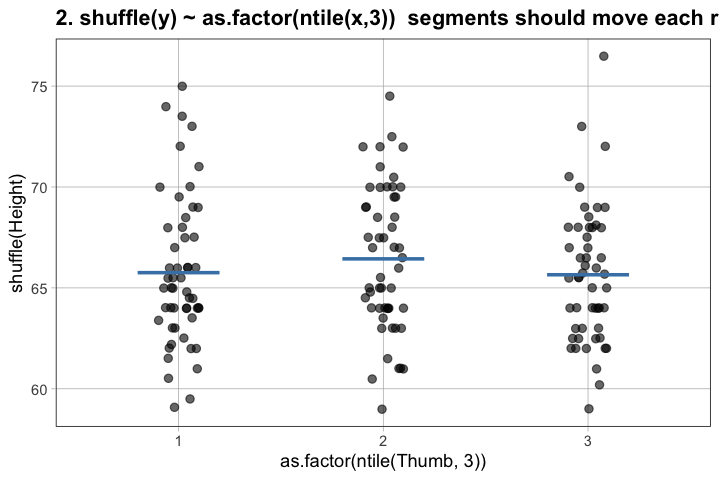

In [17]:
# 2. In-formula transformations: as.factor(ntile(...)) — the x is computed on the fly.
#    Also tests shuffle() in y. Run a few times to confirm segments move with the shuffle.
gf_jitter(shuffle(Height) ~ as.factor(ntile(Thumb, 3)), data = Fingers, width = 0.1) %>%
  gf_lm_cat(color = "steelblue") +
  labs(title = "2. shuffle(y) ~ as.factor(ntile(x,3))  segments should move each run")


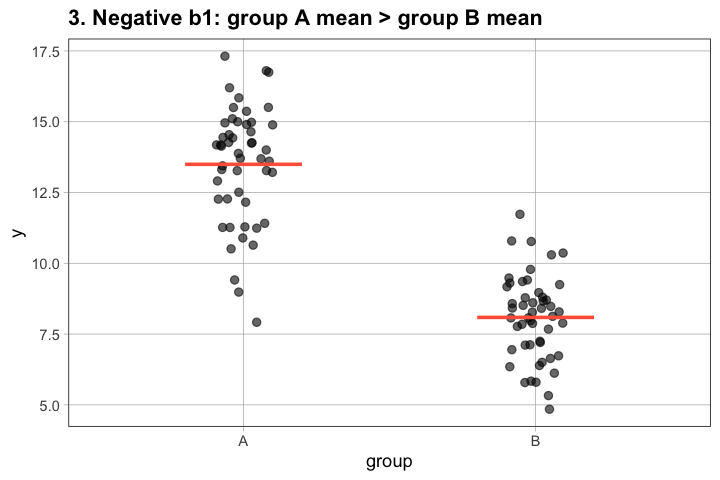

In [18]:
# 3. Negative b1 — group 2 mean is BELOW group 1.
#    Segments should: left segment HIGH (~14), right segment LOW (~8).
set.seed(99)
d_neg <- data.frame(
  group = factor(rep(c("A", "B"), each = 50)),
  y     = c(rnorm(50, mean = 14, sd = 2), rnorm(50, mean = 8, sd = 2))
)
gf_jitter(y ~ group, data = d_neg, width = 0.1) %>%
  gf_lm_cat(color = "tomato") +
  labs(title = "3. Negative b1: group A mean > group B mean")

Group means (na.rm=TRUE):
       A        B 
10.47992 14.15569 


Warning message:
"Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`)."


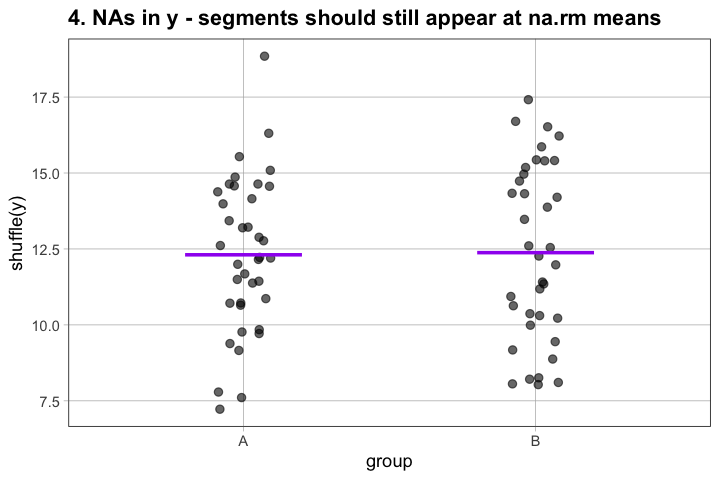

In [19]:
# 4. NAs in y — tapply uses na.rm = TRUE, so segments should still appear.
#    Verify the segment heights match mean(y, na.rm=TRUE) for each group.
set.seed(7)
d_na <- data.frame(
  group = factor(rep(c("A", "B"), each = 40)),
  y     = c(rnorm(40, mean = 10, sd = 2), rnorm(40, mean = 14, sd = 2))
)
d_na$y[c(3, 15, 27, 41, 55)] <- NA   # sprinkle some NAs

cat("Group means (na.rm=TRUE):\n")
print(tapply(d_na$y, d_na$group, mean, na.rm = TRUE))

gf_jitter(shuffle(y) ~ group, data = d_na, width = 0.1) %>%
  gf_lm_cat(color = "purple") +
  labs(title = "4. NAs in y - segments should still appear at na.rm means")


Group means:
     big     tiny 
10.06535 19.96334 
Overall mean: 10.64759 


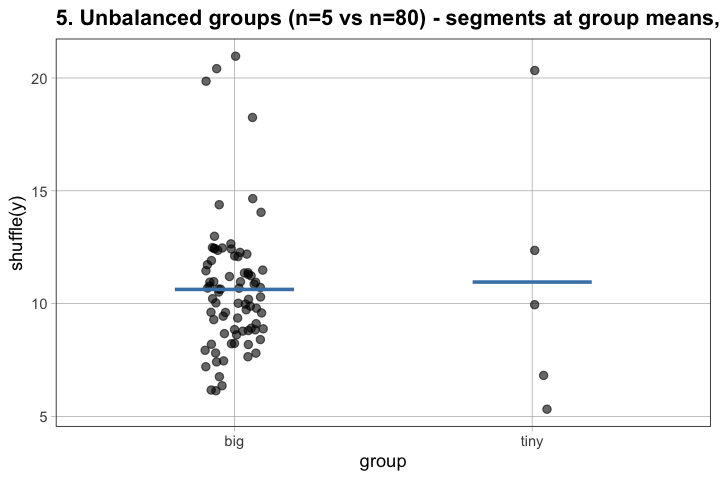

In [20]:
# 5. Unbalanced groups — n=5 in one group, n=80 in another.
#    Segment heights should still be group means, not overall mean.
#set.seed(42)
d_unbal <- data.frame(
  group = factor(c(rep("tiny", 5), rep("big", 80))),
  y     = c(rnorm(5, mean = 20, sd = 2), rnorm(80, mean = 10, sd = 2))
)
cat("Group means:\n"); print(tapply(d_unbal$y, d_unbal$group, mean))
cat("Overall mean:", mean(d_unbal$y), "\n")

gf_jitter(shuffle(y) ~ group, data = d_unbal, width = 0.1) %>%
  gf_lm_cat(color = "steelblue") +
  labs(title = "5. Unbalanced groups (n=5 vs n=80) - segments at group means, not overall mean")

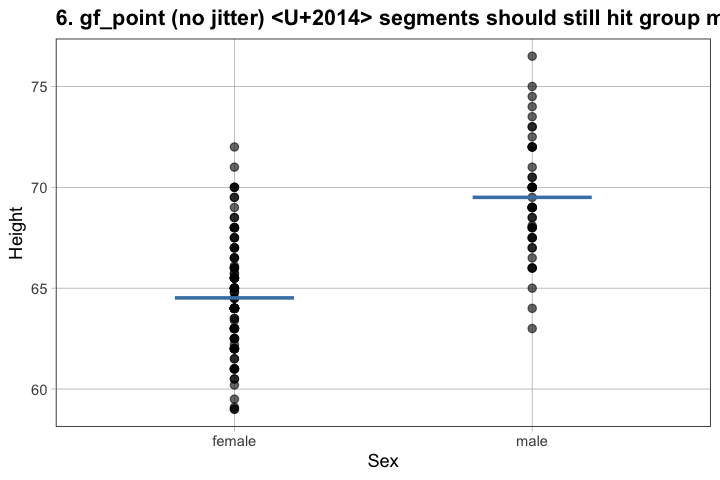

In [21]:
# 6. gf_point vs gf_jitter — no jitter means x coords are exact integers.
#    Segments should land at the same heights either way.
gf_point(Height ~ Sex, data = Fingers) %>%
  gf_lm_cat(color = "steelblue") +
  labs(title = "6. gf_point (no jitter) — segments should still hit group means")

In [22]:
# 7. Continuous x guard — should throw an informative error, not silently misbehave.
tryCatch(
  gf_point(Thumb ~ Height, data = Fingers) %>% gf_lm_cat(),
  error = function(e) cat("Expected error caught:\n", conditionMessage(e), "\n")
)

Expected error caught:
 gf_lm_cat() requires a categorical (factor or character) x variable. For continuous x, use gf_lm(). 


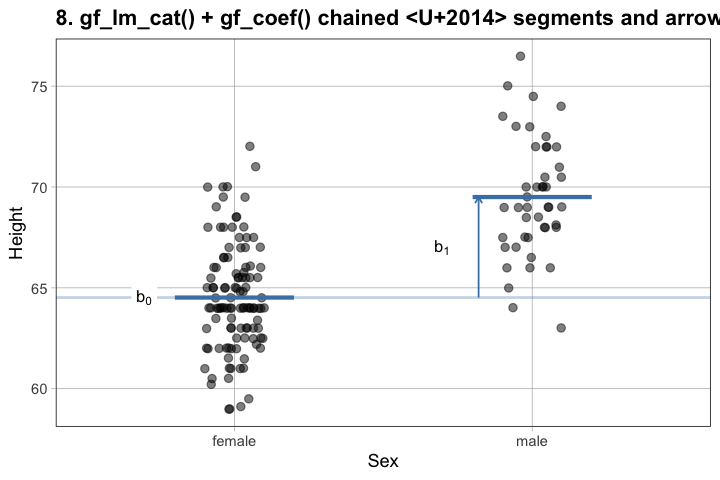

In [23]:
# 8. Chain gf_lm_cat() + gf_coef() — the primary teaching combo.
#    Segments from gf_lm_cat() should align exactly with the arrows from gf_coef().
m_sex <- lm(Height ~ Sex, data = Fingers)
gf_jitter(Height ~ Sex, data = Fingers, width = 0.1, alpha = 0.5) %>%
  gf_lm_cat(color = "steelblue", linewidth = 1.2) %>%
  gf_coef(m_sex, color = "steelblue") +
  labs(title = "8. gf_lm_cat() + gf_coef() chained — segments and arrows should align")

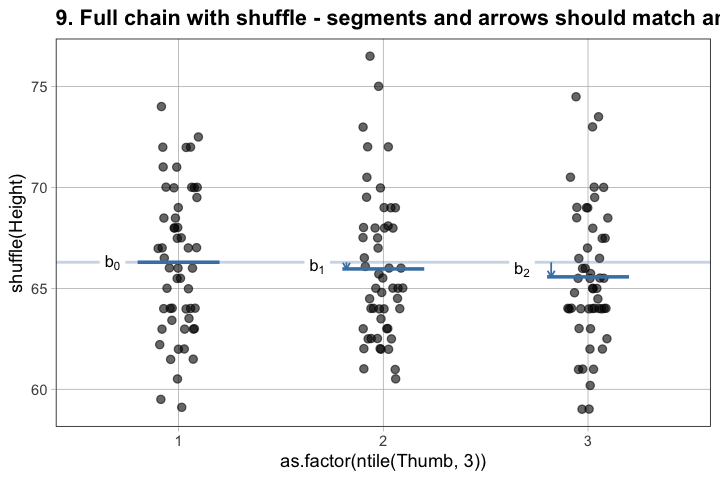

In [24]:
# 9. Full chain: gf_lm_cat() + gf_coef() with no model passed — the shuffle use case.
#    Run multiple times to confirm both segments AND arrows move with each shuffle.
gf_jitter(shuffle(Height) ~ as.factor(ntile(Thumb, 3)), data = Fingers, width = 0.1) %>%
  gf_lm_cat(color = "steelblue") %>%
  gf_coef(color = "steelblue") +
  labs(title = "9. Full chain with shuffle - segments and arrows should match and move together")

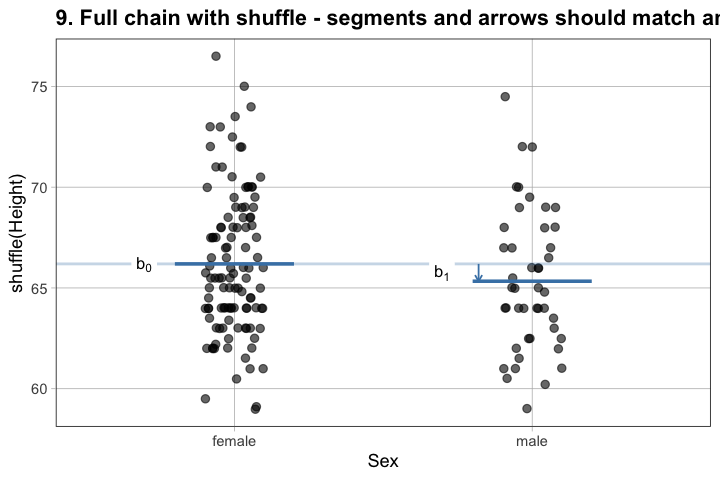

In [25]:
# 9. Full chain: gf_lm_cat() + gf_coef() with no model passed — the shuffle use case.
#    Run multiple times to confirm both segments AND arrows move with each shuffle.
gf_jitter(shuffle(Height) ~ Sex, data = Fingers, width = 0.1) %>%
  gf_lm_cat(color = "steelblue") %>%
  gf_coef(color = "steelblue") +
  labs(title = "9. Full chain with shuffle - segments and arrows should match and move together")